# HAVI QSR Demand Forecasting — 2026 Hackathon

**Task:** Forecast daily `quantity` for each restaurant × menu item on the **test** split (69,000 rows in this setup).  
**Metric:** **wMAPE** (item volume–weighted; lower is better).

**Pipeline:** Load **`qsr_demand_dataset.csv`**. **Val** = all rows with **VAL_START ≤ date ≤ VAL_END**; **test** = **FORECAST_START ≤ date ≤ FORECAST_END** (see load cell: `VAL` / `TEST` boolean masks). `quantity_fe` masks the **forecast window** so autoregressive features never use Oct–Dec actuals. **MIN_LAG** matches the forecast horizon. Stats for imputation use history before **VAL_START** and exclude val/test rows; **LightGBM** fits on train, validates on val, retrains on train+val, blends with a naïve baseline, predicts the test window, writes **`submission.csv`**.


## 0. Imports & Config

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Data & date splits (all rows from TRAIN; VAL/TEST masks built in load cell) ─
TRAIN = 'qsr_demand_dataset.csv'
OUTPUT = 'submission.csv'
FIG_DIR = 'figures'
TARGET = 'quantity'

VAL_START = pd.Timestamp('2025-09-01')
VAL_END = pd.Timestamp('2025-09-30')
FORECAST_START = pd.Timestamp('2025-10-01')
FORECAST_END = pd.Timestamp('2025-12-31')
# Next cell builds boolean masks on df, then df['_is_val'] / df['_is_test']:
#   VAL  = (df['date'] >= VAL_START) & (df['date'] <= VAL_END)
#   TEST = (df['date'] >= FORECAST_START) & (df['date'] <= FORECAST_END)

Path(FIG_DIR).mkdir(parents=True, exist_ok=True)
print(f'Data: {TRAIN} → {OUTPUT}')
print(f'Val window: {VAL_START.date()} → {VAL_END.date()}  |  '
      f'Test window: {FORECAST_START.date()} → {FORECAST_END.date()}')


Data: qsr_demand_dataset.csv → submission.csv
Val window: 2025-09-01 → 2025-09-30  |  Test window: 2025-10-01 → 2025-12-31


## 1. Load & Clean Data

In [94]:
df = pd.read_csv(TRAIN, low_memory=False)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['restaurant_id', 'menu_item_id', 'date']).reset_index(drop=True)

VAL = (df['date'] >= VAL_START) & (df['date'] <= VAL_END)
TEST = (df['date'] >= FORECAST_START) & (df['date'] <= FORECAST_END)
if (VAL & TEST).any():
    raise ValueError('VAL and TEST date ranges overlap.')
df['_is_val'] = VAL
df['_is_test'] = TEST

_dups = df.duplicated(subset=['date', 'restaurant_id', 'menu_item_id']).sum()
if _dups:
    raise ValueError(f'Duplicate (date, restaurant, item) rows: {_dups}')

_n_tr = (~df['_is_val'] & ~df['_is_test']).sum()
print(f'Rows: {len(df):,} | train {_n_tr:,} | val {df["_is_val"].sum():,} | '
      f'test {df["_is_test"].sum():,} | missing {TARGET} {df[TARGET].isna().sum():,}')


Rows: 1,369,500 | train 1,278,000 | val 22,500 | test 69,000 | missing quantity 5,475


In [95]:
# ── 1a–1b. Impute & cap (stats: not val/test, and calendar < VAL_START) ─────
train_for_stats = df[~df['_is_val'] & ~df['_is_test'] & (df['date'] < VAL_START)]
combo_median = (
    train_for_stats.groupby(['restaurant_id', 'menu_item_id'])[TARGET]
    .median()
    .rename('combo_median')
    .reset_index()
)
df = df.merge(combo_median, on=['restaurant_id', 'menu_item_id'], how='left')
global_median = train_for_stats[TARGET].median()
df['combo_median'] = df['combo_median'].fillna(global_median)
df[TARGET] = df[TARGET].fillna(df['combo_median'])
df.drop(columns='combo_median', inplace=True)

p995_table = (
    train_for_stats.groupby(['restaurant_id', 'menu_item_id'])[TARGET]
    .quantile(0.995)
    .rename('p995_cap')
    .reset_index()
)
df = df.merge(p995_table, on=['restaurant_id', 'menu_item_id'], how='left')
global_p995 = train_for_stats[TARGET].quantile(0.995)
df['p995_cap'] = df['p995_cap'].fillna(global_p995)
df['quantity_raw'] = df[TARGET].copy()
df[TARGET] = df[TARGET].clip(upper=df['p995_cap'])
df.drop(columns='p995_cap', inplace=True)

df['precip_type'] = df['precip_type'].fillna('None')

# ── 1d. quantity_fe: mask forecast window (no Oct–Dec actuals in autoregressive feats)
_fc_mask = df['date'] >= FORECAST_START
_n_fc = df.loc[_fc_mask, TARGET].notna().sum()
print(f'Forecast-window rows with non-null {TARGET} in CSV: {_n_fc:,} (masked out of quantity_fe)')
df['quantity_fe'] = df[TARGET].where(~_fc_mask)

print('Cleaning done.')
print(f'Remaining NaN in {TARGET}: {df[TARGET].isna().sum()}')


Forecast-window rows with non-null quantity in CSV: 69,000 (masked out of quantity_fe)
Cleaning done.
Remaining NaN in quantity: 0


## 2. Feature Engineering

In [96]:
# ── 2a. Calendar features ──────────────────────────────────────────────────────
df['day_of_year']    = df['date'].dt.dayofyear
df['week_of_year']   = df['date'].dt.isocalendar().week.astype(int)
df['quarter']        = df['date'].dt.quarter
df['days_from_start']= (df['date'] - df['date'].min()).dt.days  # global trend proxy

# Fourier terms for annual seasonality (k=2 harmonics)
for k in [1, 2]:
    df[f'sin_doy_{k}'] = np.sin(2 * np.pi * k * df['day_of_year'] / 365.25)
    df[f'cos_doy_{k}'] = np.cos(2 * np.pi * k * df['day_of_year'] / 365.25)

# Fourier terms for weekly seasonality (k=1)
df['sin_dow'] = np.sin(2 * np.pi * df['day_of_week_num'] / 7)
df['cos_dow'] = np.cos(2 * np.pi * df['day_of_week_num'] / 7)

# Days to/from month boundaries (captures month-start/end effects)
df['day_of_month']   = df['date'].dt.day
df['days_in_month']  = df['date'].dt.days_in_month
df['days_to_month_end'] = df['days_in_month'] - df['day_of_month']

print('Calendar features done.')

Calendar features done.


In [97]:
# ── 2b. Lag & rolling (per combo); MIN_LAG = full forecast horizon ─────────
df = df.sort_values(['restaurant_id', 'menu_item_id', 'date']).reset_index(drop=True)

MIN_LAG = (FORECAST_END - FORECAST_START).days + 1

grp = df.groupby(['restaurant_id', 'menu_item_id'])['quantity_fe']
lag_days = list(range(MIN_LAG, 358, 7)) + [364]
for lag in lag_days:
    df[f'lag_{lag}'] = grp.shift(lag)

shifted = df.groupby(['restaurant_id', 'menu_item_id'])['quantity_fe'].shift(MIN_LAG)
gcols = [df['restaurant_id'], df['menu_item_id']]
for window in [7, 14, 28]:
    df[f'roll_mean_{window}'] = shifted.groupby(gcols).transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
    df[f'roll_std_{window}'] = shifted.groupby(gcols).transform(
        lambda x: x.rolling(window, min_periods=2).std()
    )
    df[f'roll_max_{window}'] = shifted.groupby(gcols).transform(
        lambda x: x.rolling(window, min_periods=1).max()
    )

dow_grp = df.groupby(['restaurant_id', 'menu_item_id', 'day_of_week_num'])['quantity_fe']
df['same_dow_lag14'] = dow_grp.shift(14)
df['same_dow_lag15'] = dow_grp.shift(15)
df['same_dow_lag16'] = dow_grp.shift(16)
df['same_dow_mean'] = df[['same_dow_lag14', 'same_dow_lag15', 'same_dow_lag16']].mean(axis=1)

print(f'Lag/rolling done (MIN_LAG={MIN_LAG} days, {FORECAST_START.date()}–{FORECAST_END.date()}).')
lag_cols = [c for c in df.columns if c.startswith('lag_') or c.startswith('roll_') or c.startswith('same_dow')]
print(f'  Created {len(lag_cols)} lag/rolling columns')


Lag/rolling done (MIN_LAG=92 days, 2025-10-01–2025-12-31).
  Created 52 lag/rolling columns


In [98]:
# ── 2c. Prior-year slot mean + combo_mean (pre–FORECAST_START mean for Oct–Dec)
slot_cols = ['restaurant_id', 'menu_item_id', 'month', 'day_of_week_num']
train_for_stats = df[~df['_is_val'] & ~df['_is_test'] & (df['date'] < VAL_START)]


def _prior_slot_mean_strict_year(y_vals, q_vals):
    out = np.empty(len(q_vals), dtype=float)
    for i in range(len(q_vals)):
        yi = y_vals[i]
        prior = q_vals[y_vals < yi]
        out[i] = float(np.nanmean(prior)) if len(prior) else np.nan
    return out


df['_row_order'] = np.arange(len(df), dtype=np.int64)
df_slot = df.sort_values(slot_cols + ['date'])
df_slot['prior_year_avg'] = df_slot.groupby(slot_cols, group_keys=False).apply(
    lambda g: pd.Series(
        _prior_slot_mean_strict_year(g['date'].dt.year.values, g['quantity_fe'].values),
        index=g.index,
    )
)
df = df_slot.sort_values('_row_order').drop(columns='_row_order')
df = df.sort_values(['restaurant_id', 'menu_item_id', 'date']).reset_index(drop=True)

combo_train = (
    train_for_stats.groupby(['restaurant_id', 'menu_item_id'])[TARGET]
    .mean()
    .rename('combo_mean')
    .reset_index()
)
df = df.merge(combo_train, on=['restaurant_id', 'menu_item_id'], how='left')
hist_pre_forecast = df[df['date'] < FORECAST_START]
combo_pre_fc = (
    hist_pre_forecast.groupby(['restaurant_id', 'menu_item_id'])[TARGET]
    .mean()
    .rename('combo_mean_f')
    .reset_index()
)
df = df.merge(combo_pre_fc, on=['restaurant_id', 'menu_item_id'], how='left')
df['combo_mean'] = np.where(df['date'] >= FORECAST_START, df['combo_mean_f'], df['combo_mean'])
df.drop(columns=['combo_mean_f'], inplace=True)
global_mean = train_for_stats[TARGET].mean()
df['combo_mean'] = df['combo_mean'].fillna(global_mean)
df['prior_year_avg'] = df['prior_year_avg'].fillna(df['combo_mean'])
df['prior_year_avg'] = df['prior_year_avg'].fillna(0)

print('Prior-year average + combo_mean done (Oct–Dec use mean through Sep 30 history).')


Prior-year average + combo_mean done (Oct–Dec use mean through Sep 30 history).


In [99]:
# ── 2d. Event & weather interaction features ──────────────────────────────────

# Promo × weekend interaction (promotions hit harder on weekends)
df['promo_x_weekend'] = df['is_promotion'] * df['is_weekend']

# Event × weekend
df['event_x_weekend'] = df['is_special_event'] * df['is_weekend']

# Temperature binned (cold / mild / warm / hot)
df['temp_bin'] = pd.cut(
    df['avg_temp_f'],
    bins=[-np.inf, 32, 55, 75, np.inf],
    labels=[0, 1, 2, 3]
).astype(float)

# Precipitation flag (any precip vs dry)
df['has_precip'] = (df['precip_inches'] > 0).astype(int)

# Snow flag (from precip_type)
df['is_snow'] = (df['precip_type'] == 'Snow').astype(int)
df['is_rain'] = (df['precip_type'] == 'Rain').astype(int)

# Encode category & state as integers for LightGBM
for col in ['category', 'state', 'day_of_week']:
    df[col + '_enc'] = df[col].astype('category').cat.codes

print('Event/weather features done.')

Event/weather features done.


## 3. Train / Validation Split

In [100]:
# ── Feature list (no leakage: all computable at prediction time) ──────────────
# MIN_LAG set in lag cell (2b) from FORECAST_START → FORECAST_END
LAG_FEATS = [f'lag_{d}' for d in list(range(MIN_LAG, 358, 7)) + [364]]

FEATURES = [
    # Calendar
    'day_of_week_num', 'is_weekend', 'month', 'quarter',
    'day_of_month', 'days_to_month_end', 'week_of_year', 'day_of_year',
    'days_from_start',
    # Fourier
    'sin_doy_1', 'cos_doy_1', 'sin_doy_2', 'cos_doy_2',
    'sin_dow', 'cos_dow',
    # Lags (≥ horizon days; see cell 2b)
    *LAG_FEATS,
    # Rolling (anchored at MIN_LAG)
    'roll_mean_7', 'roll_std_7', 'roll_max_7',
    'roll_mean_14', 'roll_std_14', 'roll_max_14',
    'roll_mean_28', 'roll_std_28', 'roll_max_28',
    # Same-DOW (≥14 weeks back)
    'same_dow_lag14', 'same_dow_lag15', 'same_dow_lag16', 'same_dow_mean',
    # Baseline
    'prior_year_avg', 'combo_mean',
    # Events / calendar flags
    'is_holiday', 'is_special_event', 'is_promotion',
    'promo_x_weekend', 'event_x_weekend',
    # Weather
    'avg_temp_f', 'precip_inches', 'temp_bin',
    'has_precip', 'is_snow', 'is_rain',
    # Encoded categoricals
    'category_enc', 'state_enc', 'day_of_week_enc',
    # IDs (LightGBM treats as numeric; useful for global model)
    # Encode restaurant and item IDs
]

# Encode IDs
df['restaurant_enc'] = df['restaurant_id'].astype('category').cat.codes
df['item_enc']       = df['menu_item_id'].astype('category').cat.codes
FEATURES += ['restaurant_enc', 'item_enc']

# TARGET defined in config cell (imports)

# ── Splits: val/test = date windows on TRAIN (VAL_START…VAL_END, FORECAST_*) ───
# Train: neither val nor test row; Val/Test: exact row sets from those files.

train_mask = ~df['_is_val'] & ~df['_is_test']
val_mask = df['_is_val']
test_mask = df['_is_test']

train = df[train_mask].dropna(subset=FEATURES + [TARGET])
val   = df[val_mask].dropna(subset=FEATURES + [TARGET])
test  = df[test_mask]

print(f'Train rows: {len(train):,}  ({train["date"].min().date()} → {train["date"].max().date()})')
print(f'Val rows:   {len(val):,}   ({val["date"].min().date()} → {val["date"].max().date()})')
print(f'Test rows:  {len(test):,}  ({test["date"].min().date()} → {test["date"].max().date()})')
print(f'\nFeatures: {len(FEATURES)}')


Train rows: 1,005,000  (2021-12-31 → 2025-08-31)
Val rows:   22,500   (2025-09-01 → 2025-09-30)
Test rows:  69,000  (2025-10-01 → 2025-12-31)

Features: 85


## 4. wMAPE Helper

In [101]:
def wmape(y_true, y_pred, weights=None):
    """
    Weighted MAPE: sum(|actual - pred|) / sum(actual)
    weights = item volume weights (if None, uses y_true as weights → standard wMAPE)
    Lower is better.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true > 0
    if weights is None:
        weights = y_true
    w = np.array(weights)[mask]
    return np.sum(w * np.abs(y_true[mask] - y_pred[mask])) / np.sum(w * y_true[mask])


def compute_item_wmape(df_eval):
    """Compute wMAPE weighted by menu item volume (as per competition rules)."""
    item_vol = df_eval.groupby('menu_item_id')['quantity'].transform('sum')
    return wmape(df_eval['quantity'], df_eval['pred'], weights=item_vol)


print('wMAPE helper ready.')

wMAPE helper ready.


## 5. Naïve Baseline (Prior-Year Average)

In [102]:
# Naïve forecast: prior-year average for the same restaurant/item/month/DOW
val_baseline = val.copy()
val_baseline['pred'] = val_baseline['prior_year_avg'].clip(lower=0)

baseline_wmape = compute_item_wmape(val_baseline)
print(f'Naïve baseline wMAPE on Sep 2025: {baseline_wmape:.4f} ({baseline_wmape*100:.2f}%)')

Naïve baseline wMAPE on Sep 2025: 0.1595 (15.95%)


## 6. LightGBM Model

In [103]:
# ── LightGBM: MAE objective on log1p(quantity); predict expm1 at inference ───

def prepare_arrays(df_in, features, target, log_transform=True):
    X = df_in[features].values.astype(np.float32)
    y = df_in[target].values
    if log_transform:
        y = np.log1p(y)
    return X, y


LOG_TRANSFORM = True   # predict log(1+q), exponentiate output

X_train, y_train = prepare_arrays(train, FEATURES, TARGET, LOG_TRANSFORM)
X_val,   y_val   = prepare_arrays(val,   FEATURES, TARGET, LOG_TRANSFORM)

dtrain = lgb.Dataset(X_train, label=y_train, feature_name=FEATURES)
dval   = lgb.Dataset(X_val,   label=y_val,   reference=dtrain, feature_name=FEATURES)

params = {
    'objective':        'regression_l1',   # MAE — robust, MAPE-friendly
    'metric':           'mae',
    'num_leaves':       96,
    'max_depth':        12,
    'learning_rate':    0.04,
    'feature_fraction': 0.75,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'min_child_samples': 35,
    'reg_alpha':        0.15,
    'reg_lambda':       0.35,
    'verbose':          -1,
    'seed':             SEED,
    'n_jobs':           -1,
}

callbacks = [
    lgb.early_stopping(stopping_rounds=70, verbose=False),
    lgb.log_evaluation(period=200)
]

print('Training LightGBM...')
model = lgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    valid_sets=[dtrain, dval],
    valid_names=['train', 'val'],
    callbacks=callbacks,
)

print(f'\nBest iteration: {model.best_iteration}')


Training LightGBM...
[200]	train's l1: 0.179563	val's l1: 0.182997
[400]	train's l1: 0.176449	val's l1: 0.18145
[600]	train's l1: 0.17483	val's l1: 0.180989
[800]	train's l1: 0.173651	val's l1: 0.180781
[1000]	train's l1: 0.172672	val's l1: 0.180736

Best iteration: 1109


In [104]:
# ── Validate on Sep 2025 ───────────────────────────────────────────────────────
val_preds_log = model.predict(X_val, num_iteration=model.best_iteration)
val_preds = np.expm1(val_preds_log) if LOG_TRANSFORM else val_preds_log
val_preds = np.clip(val_preds, 0, None)

val_df = val.copy()
val_df['pred'] = val_preds

lgbm_wmape = compute_item_wmape(val_df)
print(f'LightGBM wMAPE on Sep 2025:      {lgbm_wmape:.4f} ({lgbm_wmape*100:.2f}%)')
print(f'Naïve baseline wMAPE on Sep 2025: {baseline_wmape:.4f} ({baseline_wmape*100:.2f}%)')
print(f'Improvement: {(baseline_wmape - lgbm_wmape)*100:.2f} pp')

LightGBM wMAPE on Sep 2025:      0.1239 (12.39%)
Naïve baseline wMAPE on Sep 2025: 0.1595 (15.95%)
Improvement: 3.56 pp


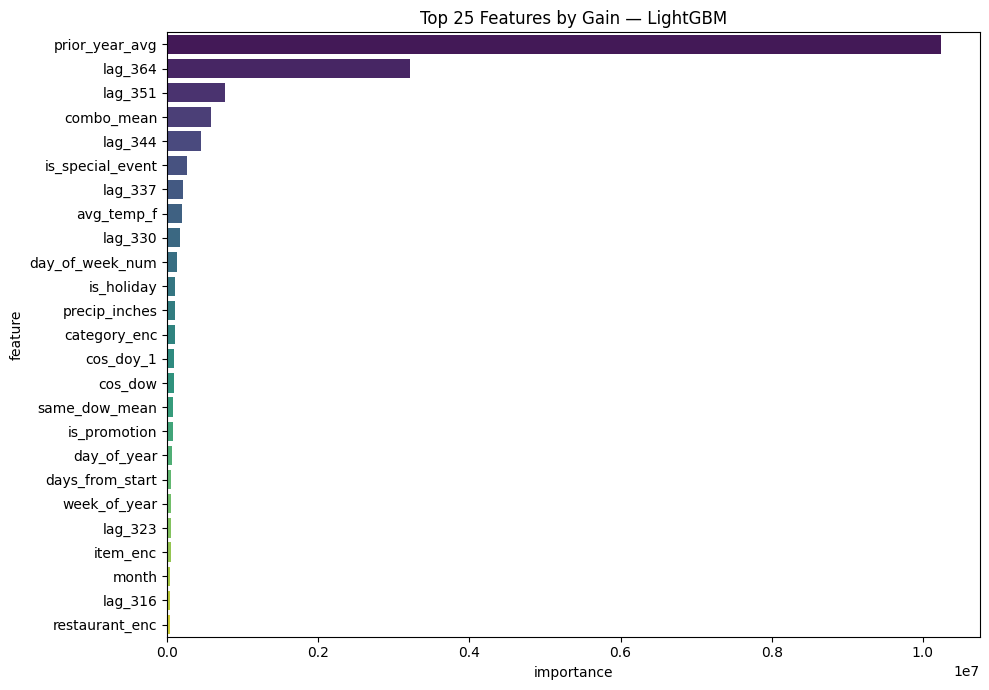

         feature   importance
  prior_year_avg 1.024361e+07
         lag_364 3.208252e+06
         lag_351 7.702976e+05
      combo_mean 5.809195e+05
         lag_344 4.529766e+05
is_special_event 2.602255e+05
         lag_337 2.083304e+05
      avg_temp_f 1.996070e+05
         lag_330 1.695964e+05
 day_of_week_num 1.260708e+05
      is_holiday 1.051536e+05
   precip_inches 1.018038e+05
    category_enc 1.003790e+05
       cos_doy_1 8.956793e+04
         cos_dow 8.818790e+04
   same_dow_mean 8.440758e+04
    is_promotion 7.704015e+04
     day_of_year 6.025892e+04
 days_from_start 5.536525e+04
    week_of_year 5.450152e+04
         lag_323 5.387768e+04
        item_enc 5.337078e+04
           month 4.041304e+04
         lag_316 3.909153e+04
  restaurant_enc 3.551168e+04


In [105]:
# ── Feature importance ────────────────────────────────────────────────────────
fi = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False).head(25)

plt.figure(figsize=(10, 7))
sns.barplot(data=fi, y='feature', x='importance', palette='viridis', hue='feature', legend=False)
plt.title('Top 25 Features by Gain — LightGBM')
plt.tight_layout()
plt.savefig(Path(FIG_DIR) / 'feature_importance.png', dpi=120)
plt.show()
print(fi.to_string(index=False))

## 7. Blend: LightGBM + Naïve Baseline

Best blend alpha (LightGBM weight): 1.00
Best blended wMAPE on Sep 2025:     0.1239 (12.39%)
Note: α was chosen by grid search on the same Sep validation set—reported wMAPE is optimistic, not unbiased.


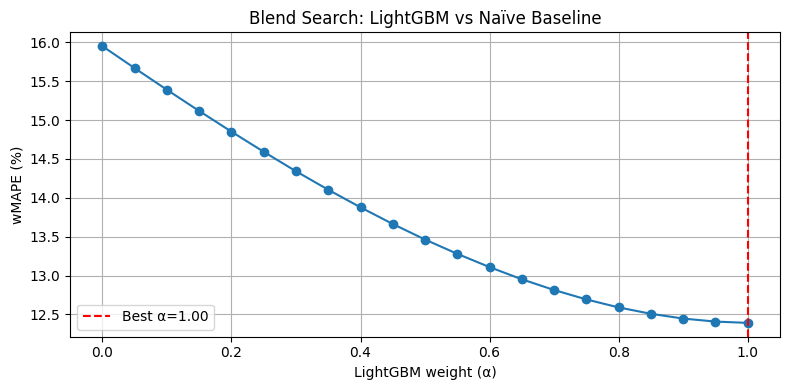

In [106]:
# Blend LightGBM with naïve baseline.
# Motivation: for combos with sparse lag history, naïve baseline is robust.
# We search for the blend weight that minimises wMAPE on the validation set.

best_alpha = 0.0
best_wmape = 1e9
results = []

for alpha in np.arange(0.0, 1.05, 0.05):
    # alpha = weight on LightGBM; (1-alpha) = weight on naïve
    blend = alpha * val_preds + (1 - alpha) * val_df['prior_year_avg'].clip(lower=0).values
    val_df['pred_blend'] = blend
    w = compute_item_wmape(val_df.rename(columns={'pred_blend': 'pred_tmp'}).assign(pred=blend))
    results.append({'alpha': alpha, 'wmape': w})
    if w < best_wmape:
        best_wmape = w
        best_alpha = alpha

results_df = pd.DataFrame(results)
print(f'Best blend alpha (LightGBM weight): {best_alpha:.2f}')
print(f'Best blended wMAPE on Sep 2025:     {best_wmape:.4f} ({best_wmape*100:.2f}%)')
print('Note: α was chosen by grid search on the same Sep validation set—reported wMAPE is optimistic, not unbiased.')

plt.figure(figsize=(8, 4))
plt.plot(results_df['alpha'], results_df['wmape'] * 100, marker='o')
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Best α={best_alpha:.2f}')
plt.xlabel('LightGBM weight (α)')
plt.ylabel('wMAPE (%)')
plt.title('Blend Search: LightGBM vs Naïve Baseline')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(Path(FIG_DIR) / 'blend_search.png', dpi=120)
plt.show()

## 8. Retrain on Full Data (Train + Val) Before Forecasting

In [107]:
# Retrain with ALL available labeled data (train + val) using the same
# num_boost_round from best_iteration found during validation.

full_train = df[~df['_is_test']].dropna(subset=FEATURES + [TARGET])
X_full, y_full = prepare_arrays(full_train, FEATURES, TARGET, LOG_TRANSFORM)

dfull = lgb.Dataset(X_full, label=y_full, feature_name=FEATURES)

final_params = {**params, 'verbose': -1}

print(f'Retraining on {len(full_train):,} rows using {model.best_iteration} rounds...')
final_model = lgb.train(
    final_params,
    dfull,
    num_boost_round=model.best_iteration,
    callbacks=[lgb.log_evaluation(period=200)]
)
print('Retrain complete.')

Retraining on 1,027,500 rows using 1109 rounds...
Retrain complete.


## 9. Generate Forecast for Oct–Dec 2025

In [108]:
# Test rows: all lags are ≥92 days so they use only pre–forecast-window history
# (computed in feature engineering). Remaining NaNs get prior_year_avg fallback.

test_df = df[test_mask].copy()

# Check for NaN in features
missing_feat = test_df[FEATURES].isna().sum()
feat_missing = missing_feat[missing_feat > 0]
if len(feat_missing) > 0:
    print('Features with NaN in test set:')
    print(feat_missing)
    # Fill lag NaNs with prior_year_avg (safe fallback)
    lag_features = [f for f in FEATURES if f.startswith('lag_') or f.startswith('roll_') or f.startswith('same_dow')]
    for col in lag_features:
        test_df[col] = test_df[col].fillna(test_df['prior_year_avg'])
    print('NaN values filled with prior_year_avg fallback.')

X_test = test_df[FEATURES].values.astype(np.float32)

# LightGBM predictions
test_preds_log = final_model.predict(X_test)
test_preds_lgbm = np.expm1(test_preds_log) if LOG_TRANSFORM else test_preds_log
test_preds_lgbm = np.clip(test_preds_lgbm, 0, None)

# Naïve baseline predictions
test_preds_naive = test_df['prior_year_avg'].clip(lower=0).values

# Blend
test_preds_blend = best_alpha * test_preds_lgbm + (1 - best_alpha) * test_preds_naive

test_df['predicted_quantity'] = test_preds_blend

print(f'Test predictions generated: {len(test_df):,} rows')
print(f'Predicted quantity stats:')
print(test_df['predicted_quantity'].describe().round(2))

Test predictions generated: 69,000 rows
Predicted quantity stats:
count    69000.00
mean        23.16
std         12.50
min          4.21
25%         14.52
50%         19.86
75%         28.23
max        119.82
Name: predicted_quantity, dtype: float64


## 10. Build & Validate Submission File

In [109]:
# ── Build submission ──────────────────────────────────────────────────────────
submission = test_df[['date', 'restaurant_id', 'menu_item_id', 'predicted_quantity']].copy()
submission['date'] = submission['date'].dt.strftime('%Y-%m-%d')
submission['predicted_quantity'] = submission['predicted_quantity'].round(2)

# ── Validate format ───────────────────────────────────────────────────────────
assert len(submission) == 69000, f'Expected 69,000 rows, got {len(submission)}'

expected_dates = pd.date_range(FORECAST_START, FORECAST_END, freq='D')
actual_dates   = pd.to_datetime(submission['date']).unique()
assert len(actual_dates) == 92, f'Expected 92 dates, got {len(actual_dates)}'

assert submission['restaurant_id'].nunique() == 15
assert submission['menu_item_id'].nunique() == 50
assert submission['predicted_quantity'].isna().sum() == 0, 'NaN in predictions!'
assert (submission['predicted_quantity'] >= 0).all(), 'Negative predictions!'

print('✓ All submission checks passed.')
print(f'\nSubmission shape: {submission.shape}')
print(submission.head(10).to_string(index=False))

submission.to_csv(OUTPUT, index=False)
print(f'\nSaved → {OUTPUT}')


✓ All submission checks passed.

Submission shape: (69000, 4)
      date restaurant_id menu_item_id  predicted_quantity
2025-10-01           R01          M01               64.33
2025-10-02           R01          M01               65.46
2025-10-03           R01          M01               72.52
2025-10-04           R01          M01               77.31
2025-10-05           R01          M01               72.75
2025-10-06           R01          M01               57.65
2025-10-07           R01          M01               51.51
2025-10-08           R01          M01               62.89
2025-10-09           R01          M01               62.60
2025-10-10           R01          M01               69.28

Saved → submission.csv


## 11. Validation Diagnostics

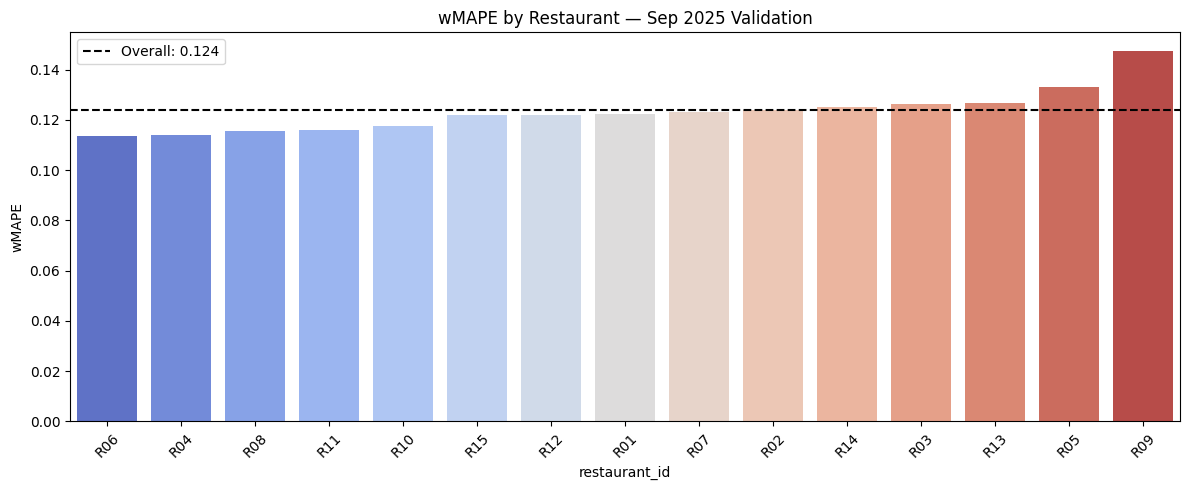

restaurant_id    wMAPE
          R06 0.113435
          R04 0.113960
          R08 0.115659
          R11 0.115995
          R10 0.117404
          R15 0.121795
          R12 0.122011
          R01 0.122408
          R07 0.123198
          R02 0.123750
          R14 0.125203
          R03 0.126282
          R13 0.126697
          R05 0.133017
          R09 0.147456


In [110]:
# ── wMAPE by restaurant on val set ───────────────────────────────────────────
val_df['pred_final'] = best_alpha * val_preds + (1 - best_alpha) * val_df['prior_year_avg'].clip(lower=0).values

per_rest = []
for rid, grp in val_df.groupby('restaurant_id'):
    w = wmape(grp['quantity'], grp['pred_final'])
    per_rest.append({'restaurant_id': rid, 'wMAPE': w})
per_rest_df = pd.DataFrame(per_rest).sort_values('wMAPE')

plt.figure(figsize=(12, 5))
sns.barplot(data=per_rest_df, x='restaurant_id', y='wMAPE', palette='coolwarm', hue='restaurant_id', legend=False)
plt.axhline(best_wmape, linestyle='--', color='black', label=f'Overall: {best_wmape:.3f}')
plt.title('wMAPE by Restaurant — Sep 2025 Validation')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(Path(FIG_DIR) / 'val_by_restaurant.png', dpi=120)
plt.show()
print(per_rest_df.to_string(index=False))

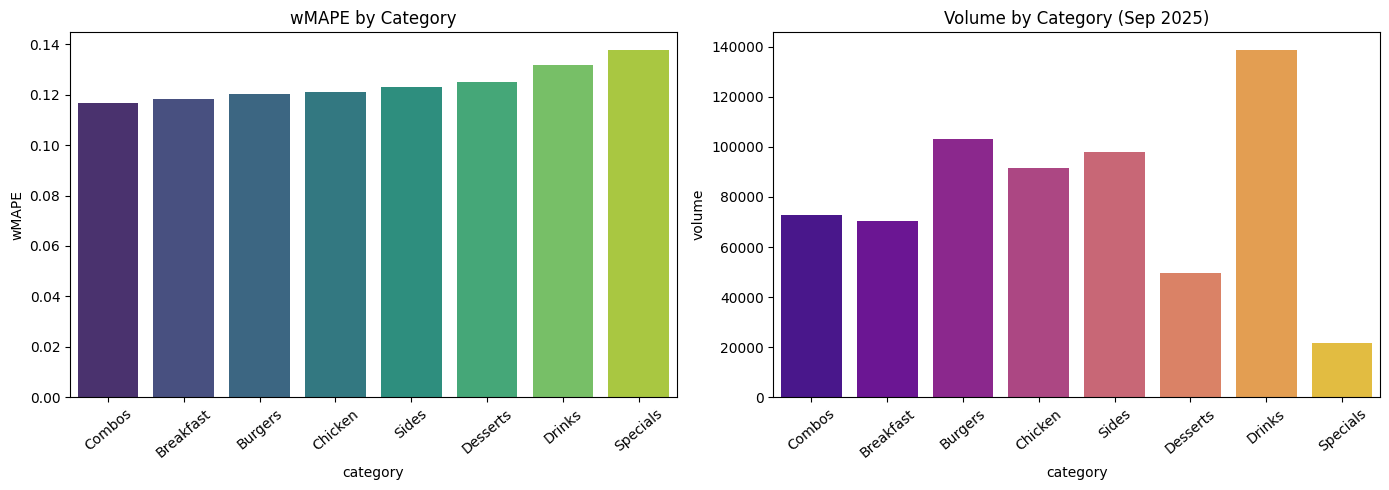

 category    wMAPE     volume
   Combos 0.116646  72954.640
Breakfast 0.118447  70345.620
  Burgers 0.120390 103190.880
  Chicken 0.121180  91728.300
    Sides 0.123111  97797.310
 Desserts 0.125258  49444.325
   Drinks 0.131996 138855.405
 Specials 0.137885  21715.665


In [111]:
# ── wMAPE by category on val set ──────────────────────────────────────────────
per_cat = []
for cat, grp in val_df.groupby('category'):
    w = wmape(grp['quantity'], grp['pred_final'])
    per_cat.append({'category': cat, 'wMAPE': w, 'volume': grp['quantity'].sum()})
per_cat_df = pd.DataFrame(per_cat).sort_values('wMAPE')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=per_cat_df, x='category', y='wMAPE',
            palette='viridis', hue='category', legend=False, ax=axes[0])
axes[0].set_title('wMAPE by Category')
axes[0].tick_params(axis='x', rotation=40)

sns.barplot(data=per_cat_df, x='category', y='volume',
            palette='plasma', hue='category', legend=False, ax=axes[1])
axes[1].set_title('Volume by Category (Sep 2025)')
axes[1].tick_params(axis='x', rotation=40)

plt.tight_layout()
plt.savefig(Path(FIG_DIR) / 'val_by_category.png', dpi=120)
plt.show()
print(per_cat_df.to_string(index=False))

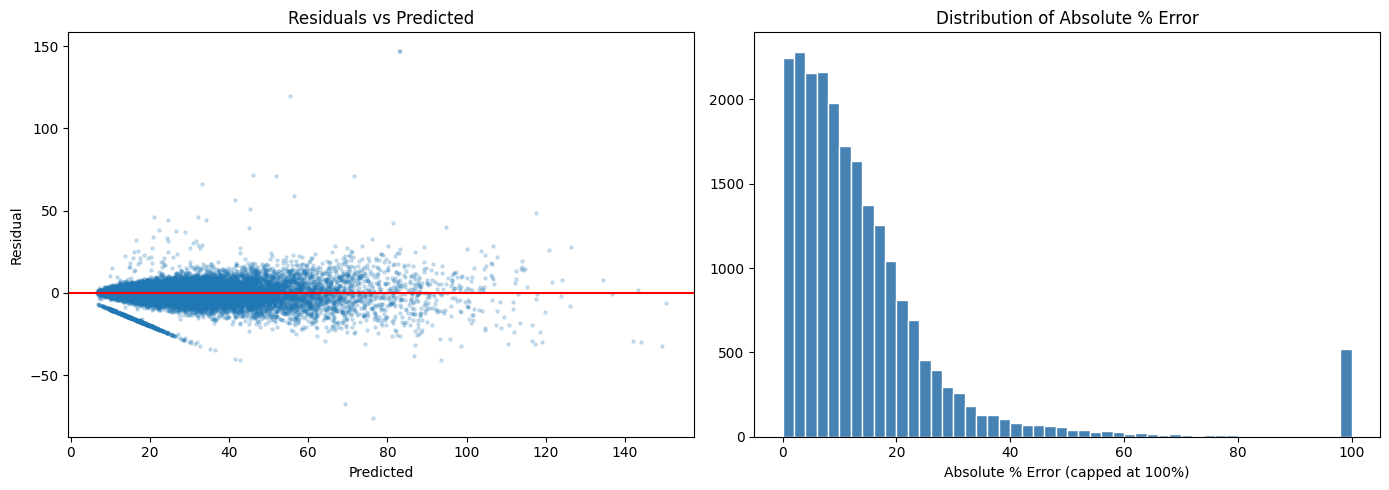


Median absolute % error: 10.5%
90th pct absolute % error: 28.3%


In [112]:
# ── Residual plot ─────────────────────────────────────────────────────────────
val_df['residual'] = val_df['quantity'] - val_df['pred_final']
val_df['pct_error'] = (val_df['residual'].abs() / val_df['quantity'].clip(lower=1)) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(val_df['pred_final'], val_df['residual'], alpha=0.2, s=5)
axes[0].axhline(0, color='red')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(val_df['pct_error'].clip(upper=100), bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Absolute % Error (capped at 100%)')
axes[1].set_title('Distribution of Absolute % Error')

plt.tight_layout()
plt.savefig(Path(FIG_DIR) / 'residuals.png', dpi=120)
plt.show()

print(f'\nMedian absolute % error: {val_df["pct_error"].median():.1f}%')
print(f'90th pct absolute % error: {val_df["pct_error"].quantile(0.9):.1f}%')

## 12. Accuracy Metrics Summary

In [113]:
print(f'LightGBM wMAPE on Sep 2025:      {lgbm_wmape:.4f} ({lgbm_wmape*100:.2f}%)')
print(f'Naïve baseline wMAPE on Sep 2025: {baseline_wmape:.4f} ({baseline_wmape*100:.2f}%)')
print(f'Best blended wMAPE on Sep 2025:     {best_wmape:.4f} ({best_wmape*100:.2f}%)')
print(f'Blend alpha (LightGBM weight):      {best_alpha:.2f}')
print(f'Improvement (Blended vs Naïve):     {(baseline_wmape - best_wmape)*100:.2f} pp')

LightGBM wMAPE on Sep 2025:      0.1239 (12.39%)
Naïve baseline wMAPE on Sep 2025: 0.1595 (15.95%)
Best blended wMAPE on Sep 2025:     0.1239 (12.39%)
Blend alpha (LightGBM weight):      1.00
Improvement (Blended vs Naïve):     3.56 pp


## 13. Actual vs. Predicted Visualization

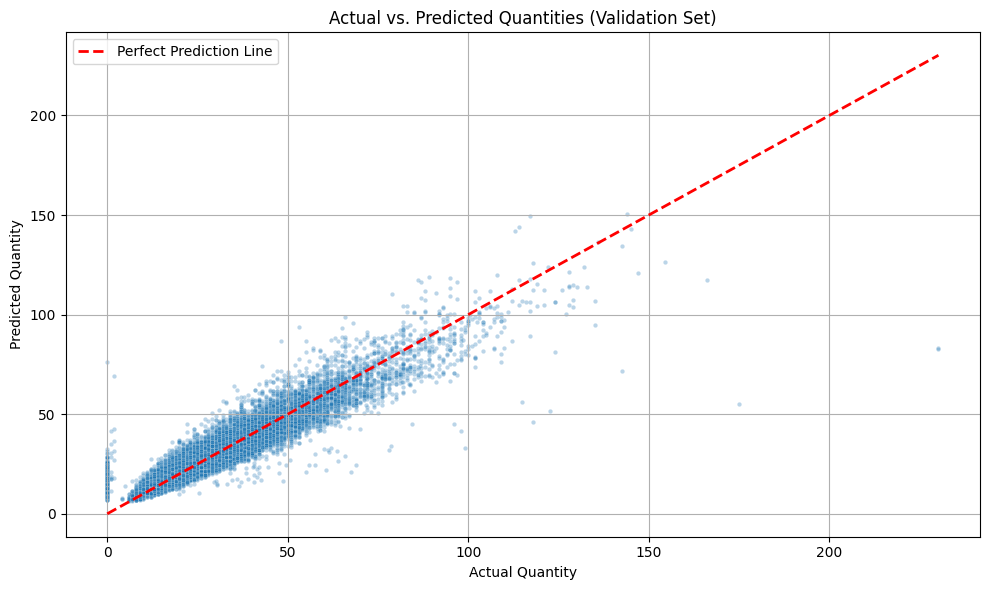


Sample of Actual vs. Predicted values:


,date,restaurant_id,menu_item_id,quantity,pred_final
489246,2025-09-01,R06,M18,40.545,39.375777
136830,2025-09-03,R02,M25,33.000,35.079340
1175827,2025-09-06,R13,M44,23.000,27.577583
713853,2025-09-10,R08,M41,25.000,20.228749
827069,2025-09-14,R10,M03,12.000,16.961705
9022,2025-09-15,R01,M05,31.000,35.935597
533088,2025-09-19,R06,M42,27.000,29.785125
962203,2025-09-24,R11,M27,21.000,22.708558
523964,2025-09-25,R06,M37,15.000,16.188252
544051,2025-09-26,R06,M48,17.000,15.249085


In [114]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=val_df['quantity'], y=val_df['pred_final'], alpha=0.3, s=10)
plt.plot([val_df['quantity'].min(), val_df['quantity'].max()],
         [val_df['quantity'].min(), val_df['quantity'].max()],
         'r--', lw=2, label='Perfect Prediction Line')
plt.xlabel('Actual Quantity')
plt.ylabel('Predicted Quantity')
plt.title('Actual vs. Predicted Quantities (Validation Set)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(Path(FIG_DIR) / 'actual_vs_predicted.png', dpi=120)
plt.show()

# Also show a sample of actual vs predicted values
print('\nSample of Actual vs. Predicted values:')
display(val_df[['date', 'restaurant_id', 'menu_item_id', 'quantity', 'pred_final']].sample(10, random_state=SEED).sort_values('date'))

## 14. Test set: wMAPE vs actuals (competition metric)


In [115]:
# Item-weighted MAPE on test period — same spirit as the competition leaderboard.
# Uses rows where `quantity` is present (full local test split has labels for all rows).
_test_lbl = test_df['quantity'].notna().sum()
print(f'Test rows with actual quantity for scoring: {_test_lbl:,} / {len(test_df):,}')

if _test_lbl == 0:
    print('No test-period labels in test_df — cannot compute test wMAPE.')
else:
    _sub = test_df.dropna(subset=['quantity'])
    if len(_sub) < len(test_df):
        print('Warning: computing wMAPE only on rows with non-null quantity.')

    def _mape(y_true, y_pred):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        mask = y_true > 0
        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    test_wmape = compute_item_wmape(_sub.rename(columns={'predicted_quantity': 'pred'}))
    test_mape = _mape(_sub['quantity'], _sub['predicted_quantity'])
    print(f'Test wMAPE (Oct–Dec 2025, item-weighted): {test_wmape:.4f} ({test_wmape*100:.2f}%)')
    print(f'Test MAPE (unweighted %):                {test_mape:.4f}%')


Test rows with actual quantity for scoring: 69,000 / 69,000
Test wMAPE (Oct–Dec 2025, item-weighted): 0.1274 (12.74%)
Test MAPE (unweighted %):                14.3982%
